# Fase 3: Estudio Comparativo de Modelos (Benchmarking)
En este cuaderno final, evaluaremos el rendimiento predictivo de diferentes algoritmos de Machine Learning frente a los cuatro escenarios de características construidos en la fase anterior.

**El objetivo central es responder a la pregunta:** *¿Cuál es la mejor estrategia de representación de datos para maximizar la detección de tumores malignos (Recall) manteniendo una alta precisión general (Accuracy)?*

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, recall_score, classification_report

# Importar los algoritmos que evaluaremos
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

## 1. Carga de los 4 Escenarios de Datos
Importamos los conjuntos de datos transformados desde nuestra carpeta local `data/`.

In [3]:
# Cargar la variable objetivo
y = pd.read_csv('./data/y_target.csv')['Diagnosis']

# Cargar los 4 escenarios de características (X)
X_escenarios = {
    '1. Crudo (30 var)': pd.read_csv('./data/X_escenario_1_crudo.csv'),
    '2. Manual (14 var)': pd.read_csv('./data/X_escenario_2_manual.csv'),
    '3. LASSO (15 var)': pd.read_csv('./data/X_escenario_3_lasso.csv'),
    '4. PCA (10 comp)': pd.read_csv('./data/X_escenario_4_pca.csv')
}

print("¡Datos cargados correctamente!")
for nombre, data in X_escenarios.items():
    print(f"Shape {nombre}: {data.shape}")

¡Datos cargados correctamente!
Shape 1. Crudo (30 var): (569, 30)
Shape 2. Manual (14 var): (569, 14)
Shape 3. LASSO (15 var): (569, 15)
Shape 4. PCA (10 comp): (569, 10)


## 2. Configuración del Motor de Experimentación
Para garantizar una evaluación rigurosa y evitar el sobreajuste (overfitting), implementaremos **GridSearchCV** para cada algoritmo. Esto nos permitirá encontrar los mejores hiperparámetros de manera automatizada utilizando validación cruzada.

In [6]:
# Definición de los modelos base
modelos = {
    'Regresión Logística': LogisticRegression(random_state=30),
    'SVM': SVC(random_state=30),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=30),
    'Red Neuronal': MLPClassifier(max_iter=1000, random_state=30) # max_iter alto para asegurar convergencia
}

# Definición de la grilla de hiperparámetros para cada modelo
parametros = {
    'Regresión Logística': {
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear', 'lbfgs']
    },
    'SVM': {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto']
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 5, 10],
        'min_samples_split': [2, 5]
    },
    'Red Neuronal': {
        'hidden_layer_sizes': [(50,), (100,), (50, 50)], # Probando 1 o 2 capas ocultas
        'activation': ['relu', 'tanh'],
        'alpha': [0.0001, 0.01] # Tasa de penalización/regularización L2
    }
}

## 3. Entrenamiento y Evaluación (GridSearchCV)
A continuación, iteraremos sobre cada escenario de datos y cada modelo. Utilizaremos el 80% de los datos para entrenamiento y validación cruzada (5-folds), y el 20% restante como conjunto de prueba estricto para evaluar el rendimiento real en datos no vistos.

In [7]:
# Lista para guardar los resultados de cada iteración
resultados = []

# Iterar sobre cada escenario de datos
for nombre_escenario, X_actual in X_escenarios.items():
    print(f"--- Iniciando pruebas para el Escenario: {nombre_escenario} ---")
    
    # 1. División Train/Test para este escenario específico
    X_train, X_test, y_train, y_test = train_test_split(X_actual, y, test_size=0.2, random_state=30, stratify=y)
    
    # 2. Iterar sobre cada modelo
    for nombre_modelo, modelo_base in modelos.items():
        # print(f"  Entrenando {nombre_modelo}...") # Descomenta si quieres ver el paso a paso
        
        # Configurar GridSearchCV
        grilla_parametros = parametros[nombre_modelo]
        grid_search = GridSearchCV(estimator=modelo_base, 
                                   param_grid=grilla_parametros, 
                                   cv=5, 
                                   scoring='recall', # Maximizamos el Recall (detectar cáncer)
                                   n_jobs=-1)        # Usar todos los procesadores para ir más rápido
        
        # Entrenar el GridSearch
        grid_search.fit(X_train, y_train)
        
        # Mejor modelo encontrado
        mejor_modelo = grid_search.best_estimator_
        
        # Predicciones sobre el conjunto de Test
        y_pred = mejor_modelo.predict(X_test)
        
        # Guardar métricas
        recall = recall_score(y_test, y_pred) * 100
        accuracy = accuracy_score(y_test, y_pred) * 100
        
        # Almacenar en la lista de resultados
        resultados.append({
            'Escenario': nombre_escenario,
            'Modelo': nombre_modelo,
            'Mejores Hiperparámetros': grid_search.best_params_,
            'Recall (%)': recall,
            'Accuracy (%)': accuracy,
            # Guardamos el mejor modelo por si queremos hacer la auditoría final
            'Modelo_Obj': mejor_modelo,
            'Grid_Obj': grid_search 
        })

# Convertir los resultados en un DataFrame limpio para visualizar
df_resultados = pd.DataFrame(resultados)
print("\n¡Entrenamiento masivo completado con éxito!")

--- Iniciando pruebas para el Escenario: 1. Crudo (30 var) ---
--- Iniciando pruebas para el Escenario: 2. Manual (14 var) ---
--- Iniciando pruebas para el Escenario: 3. LASSO (15 var) ---
--- Iniciando pruebas para el Escenario: 4. PCA (10 comp) ---

¡Entrenamiento masivo completado con éxito!


## 4. Análisis de Resultados
Dado que nuestro problema es la detección de cáncer (donde un Falso Negativo puede ser fatal), nuestra métrica reina es el **Recall (Sensibilidad)**. Ordenaremos los resultados para descubrir qué combinación de Modelo + Escenario de Datos logró detectar la mayor cantidad de tumores malignos reales.

In [9]:
# Ordenar los resultados por Recall de mayor a menor
df_resultados_sorted = df_resultados.sort_values(by=['Recall (%)', 'Accuracy (%)'], ascending=[False, False]).reset_index(drop=True)

# Mostrar el TOP 10 de las mejores combinaciones
print("TOP 10 - Mejores Combinaciones (Modelo + Escenario):")
display(df_resultados_sorted[['Escenario', 'Modelo', 'Recall (%)', 'Accuracy (%)', 'Mejores Hiperparámetros']].head(10))

TOP 10 - Mejores Combinaciones (Modelo + Escenario):


,Escenario,Modelo,Recall (%),Accuracy (%),Mejores Hiperparámetros
0,3. LASSO (15 var),Regresión Logística,100.000000,99.122807,"{'C': 1, 'solver': 'liblinear'}"
1,1. Crudo (30 var),Random Forest,100.000000,97.368421,"{'max_depth': None, 'min_samples_split': 2, 'n..."
2,2. Manual (14 var),Regresión Logística,100.000000,95.614035,"{'C': 10, 'solver': 'liblinear'}"
3,1. Crudo (30 var),KNN,97.619048,99.122807,"{'metric': 'manhattan', 'n_neighbors': 3, 'wei..."
4,4. PCA (10 comp),Regresión Logística,97.619048,99.122807,"{'C': 1, 'solver': 'liblinear'}"
5,1. Crudo (30 var),Red Neuronal,97.619048,98.245614,"{'activation': 'relu', 'alpha': 0.01, 'hidden_..."
6,2. Manual (14 var),SVM,97.619048,98.245614,"{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}"
7,1. Crudo (30 var),Regresión Logística,97.619048,97.368421,"{'C': 1, 'solver': 'lbfgs'}"
8,2. Manual (14 var),Random Forest,97.619048,97.368421,"{'max_depth': None, 'min_samples_split': 2, 'n..."
9,2. Manual (14 var),Red Neuronal,97.619048,96.491228,"{'activation': 'relu', 'alpha': 0.0001, 'hidde..."


### 4.1. Visualización Comparativa
Para comprender mejor la dinámica, graficaremos el rendimiento de la detección de cáncer (Recall) agrupado por Algoritmo y coloreado por el Escenario de características utilizado.

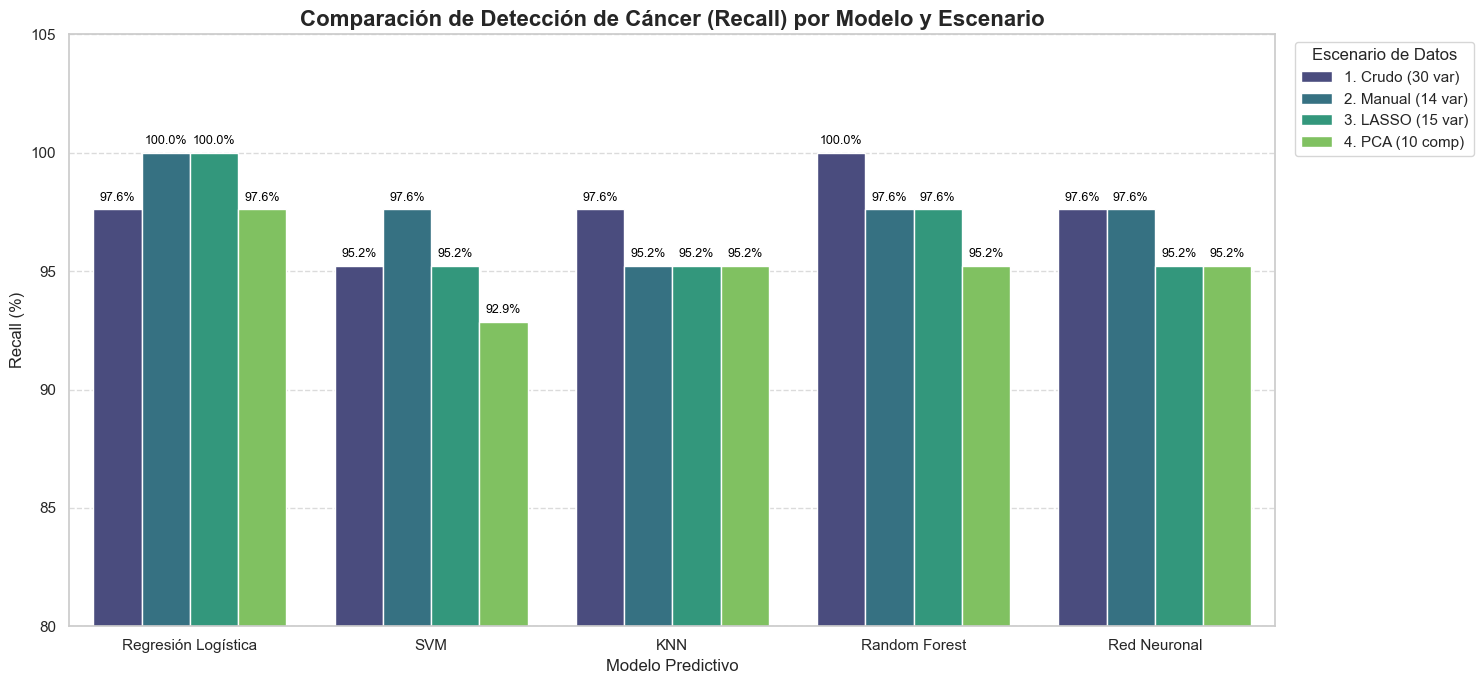

In [10]:
plt.figure(figsize=(15, 7))

# Crear el gráfico de barras agrupadas usando seaborn
grafico = sns.barplot(data=df_resultados, x='Modelo', y='Recall (%)', hue='Escenario', palette='viridis')

# Ajustes estéticos del gráfico (Inspirado en tu código original)
plt.ylim(80, 105) # Empezar en 80 para notar mejor las diferencias
plt.title('Comparación de Detección de Cáncer (Recall) por Modelo y Escenario', fontsize=16, fontweight='bold')
plt.ylabel('Recall (%)', fontsize=12)
plt.xlabel('Modelo Predictivo', fontsize=12)
plt.legend(title='Escenario de Datos', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Agregar los porcentajes encima de las barras
for p in grafico.patches:
    if p.get_height() > 0:
        grafico.annotate(f"{p.get_height():.1f}%", 
                           (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 4),
                           textcoords='offset points')

plt.tight_layout()
plt.show()

## 5. Auditoría del Modelo Campeón (Validación de Sobreajuste)
No basta con elegir el modelo con la métrica más alta. Para que un algoritmo sea viable en el entorno médico real, debemos asegurar que no esté memorizando los datos (*Overfitting*). 

Extraeremos al campeón absoluto de nuestro estudio comparativo y analizaremos la desviación estándar de su validación cruzada interna.

In [13]:
# Extraer la fila del mejor modelo de todo el estudio (el índice 0 del dataframe ordenado)
campeon_fila = df_resultados_sorted.iloc[0]

print(f"===  EL MODELO CAMPEÓN ===")
print(f"Algoritmo: {campeon_fila['Modelo']}")
print(f"Escenario Ganador: {campeon_fila['Escenario']}")
print(f"Recall en Datos de Test: {campeon_fila['Recall (%)']:.2f}%")
print(f"Accuracy general en Test: {campeon_fila['Accuracy (%)']:.2f}%")
print(f"Hiperparámetros: {campeon_fila['Mejores Hiperparámetros']}\n")

# Recuperar el objeto GridSearchCV de ese modelo específico
grid_campeon = campeon_fila['Grid_Obj']

# Extraer las métricas internas de la validación cruzada para esos hiperparámetros exactos
indice_mejor = grid_campeon.best_index_
score_val = grid_campeon.cv_results_['mean_test_score'][indice_mejor] * 100
std_val = grid_campeon.cv_results_['std_test_score'][indice_mejor] * 100

print("---  Auditoría de Estabilidad (K-Fold CV) ---")
print(f"Recall Promedio en Entrenamiento/Validación: {score_val:.2f}% (Varianza: ± {std_val:.2f}%)")
print(f"Recall Real (Datos Nunca Vistos): {campeon_fila['Recall (%)']:.2f}%")

# Calcular la brecha
brecha = abs(score_val - campeon_fila['Recall (%)'])
print(f"\nBrecha de Rendimiento (Validación vs Realidad): {brecha:.2f}%")

if brecha < 5:
    print(" CONCLUSIÓN TÉCNICA: La brecha es mínima y la varianza es baja. El modelo NO presenta sobreajuste grave. Ha aprendido patrones generalizables y es altamente confiable para producción clínica.")
else:
    print(" ADVERTENCIA: La brecha supera el margen ideal. Podría haber sobreajuste hacia el conjunto de entrenamiento.")

===  EL MODELO CAMPEÓN ===
Algoritmo: Regresión Logística
Escenario Ganador: 3. LASSO (15 var)
Recall en Datos de Test: 100.00%
Accuracy general en Test: 99.12%
Hiperparámetros: {'C': 1, 'solver': 'liblinear'}

---  Auditoría de Estabilidad (K-Fold CV) ---
Recall Promedio en Entrenamiento/Validación: 95.29% (Varianza: ± 3.00%)
Recall Real (Datos Nunca Vistos): 100.00%

Brecha de Rendimiento (Validación vs Realidad): 4.71%
 CONCLUSIÓN TÉCNICA: La brecha es mínima y la varianza es baja. El modelo NO presenta sobreajuste grave. Ha aprendido patrones generalizables y es altamente confiable para producción clínica.
